Welcome to SkillCraft II Data Science Project
Columns: ['GameID', 'LeagueIndex', 'Age', 'HoursPerWeek', 'TotalHours', 'APM', 'SelectByHotkeys', 'AssignToHotkeys', 'UniqueHotkeys', 'MinimapAttacks', 'MinimapRightClicks', 'NumberOfPACs', 'GapBetweenPACs', 'ActionLatency', 'ActionsInPAC', 'TotalMapExplored', 'WorkersMade', 'UniqueUnitsMade', 'ComplexUnitsMade', 'ComplexAbilitiesUsed']
TOP 5 rows:
   GameID  LeagueIndex Age HoursPerWeek TotalHours       APM  SelectByHotkeys  \
0      52            5  27           10       3000  143.7180         0.003515   
1      55            5  23           10       5000  129.2322         0.003304   
2      56            4  30           10        200   69.9612         0.001101   
3      57            3  19           20        400  107.6016         0.001034   
4      58            3  32           10        500  122.8908         0.001136   

   AssignToHotkeys  UniqueHotkeys  MinimapAttacks  MinimapRightClicks  \
0         0.000220              7        0.

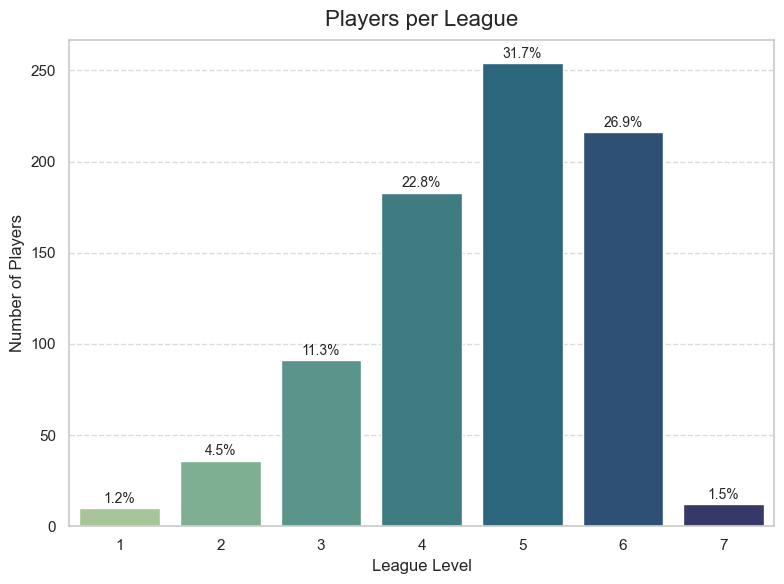


Graph 2: How fast are players reacting with trend!


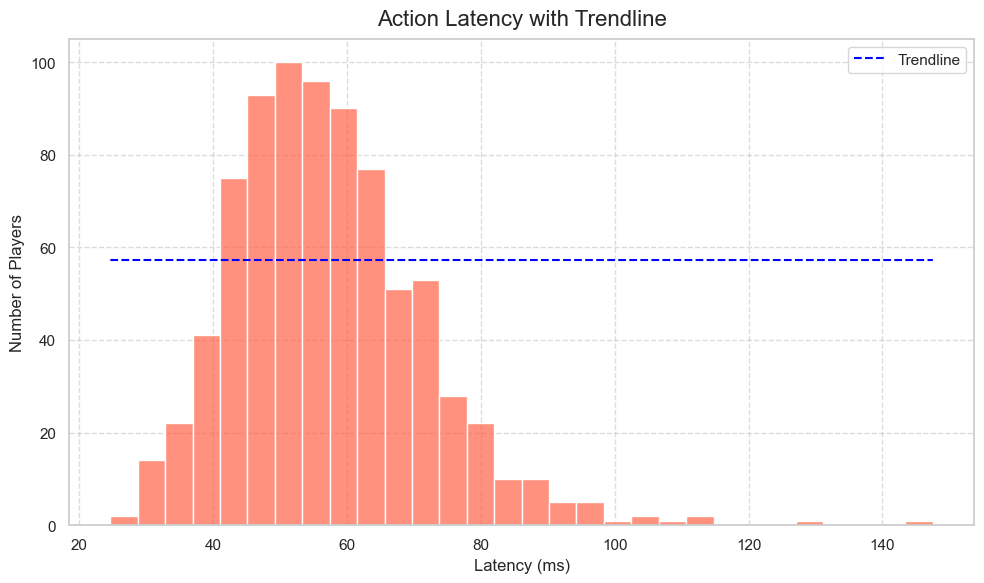


Graph 3: APM trends across leagues!


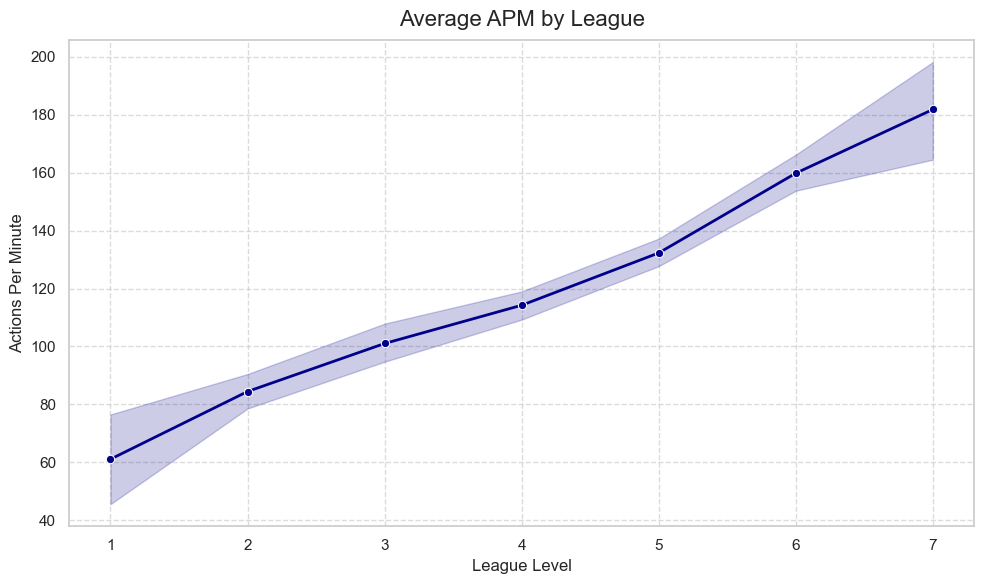


Graph 4: Units built by league!


<Figure size 1200x600 with 0 Axes>

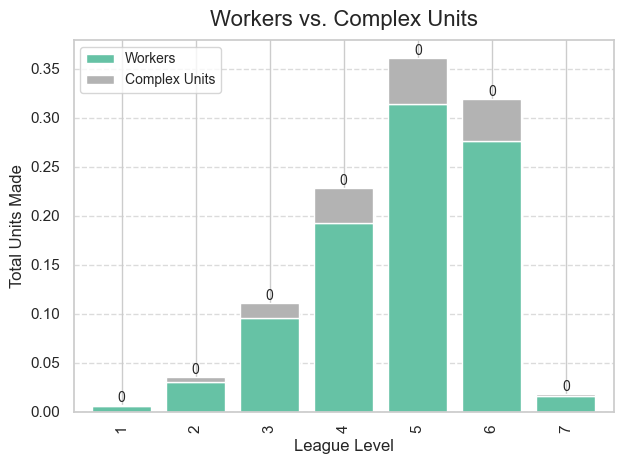


Graph 5: Average APM per league!


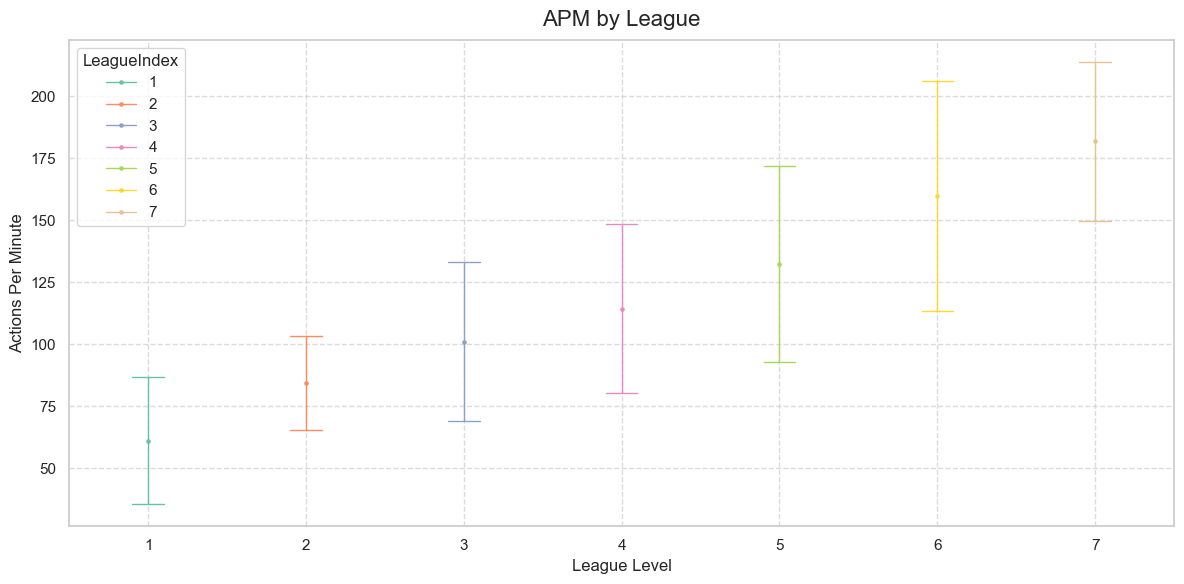


Graph 6: Speed vs. reaction time!


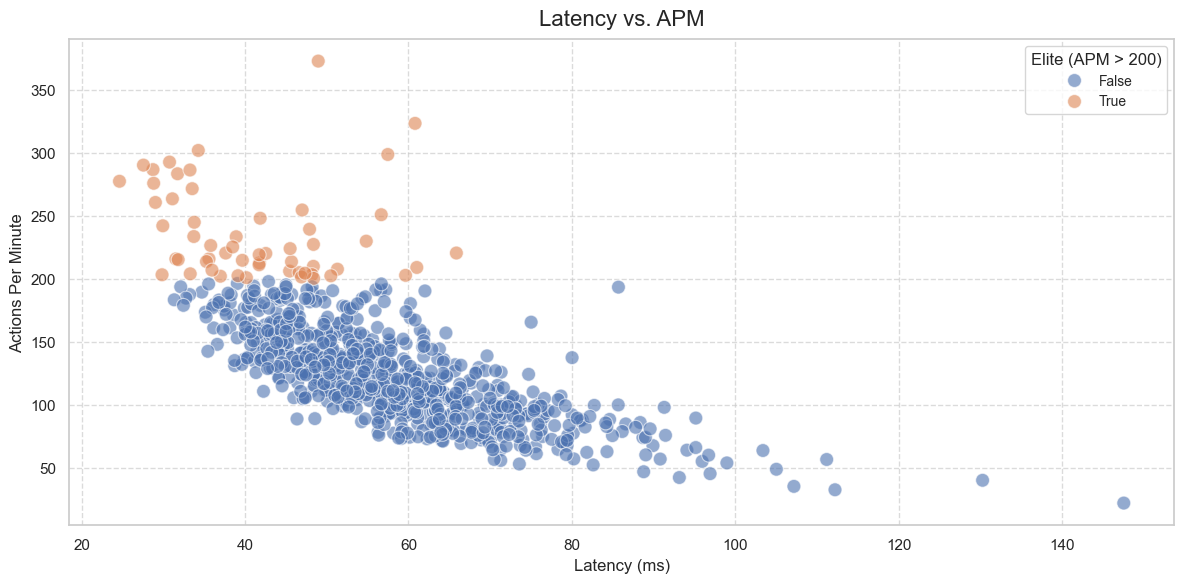


Graph 7: How metrics connect!


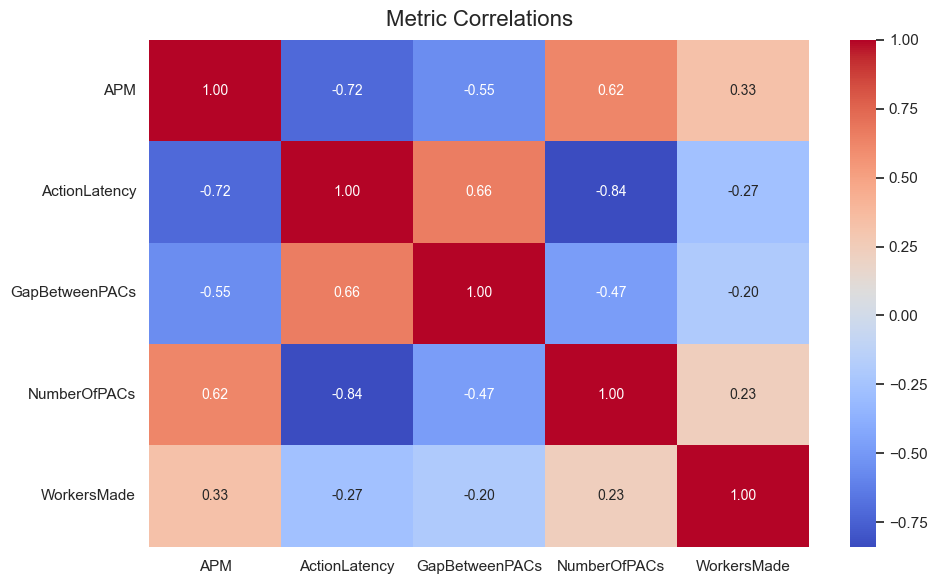


EDA: Digging Deeper!

Stats Summary:
            GameID  LeagueIndex         APM  SelectByHotkeys  AssignToHotkeys  \
count   802.000000   802.000000  802.000000       802.000000       802.000000   
mean   4749.602244     4.659601  129.750425         0.004756         0.000435   
std    2701.519972     1.225036   45.612219         0.004709         0.000202   
min      72.000000     1.000000   22.059600         0.000024         0.000026   
25%    2336.000000     4.000000   98.687550         0.001902         0.000301   
50%    4926.000000     5.000000  124.283400         0.003122         0.000425   
75%    7086.250000     6.000000  155.803350         0.005936         0.000549   
max    9256.000000     7.000000  372.642600         0.042258         0.001387   

       UniqueHotkeys  MinimapAttacks  MinimapRightClicks  NumberOfPACs  \
count     802.000000      802.000000          802.000000    802.000000   
mean        5.138404        0.000138            0.000479      0.003826   
std       

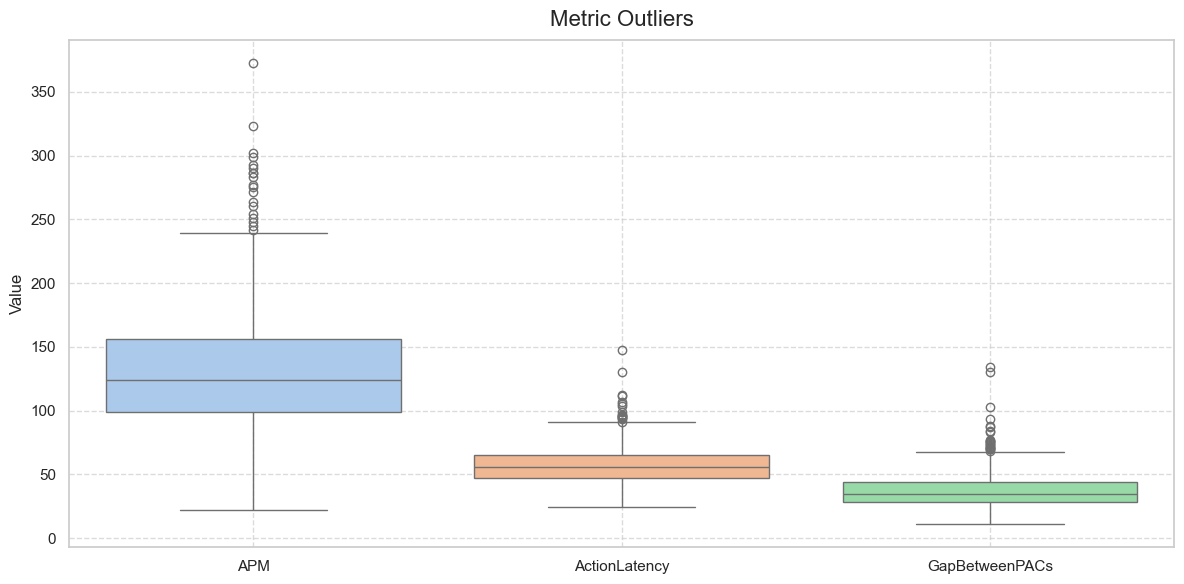


Stats Intro: Easy Number Crunching!

Mean and Median APM:
Mean APM: 129.8
Median APM: 124.3

Graph 9: APM histogram!


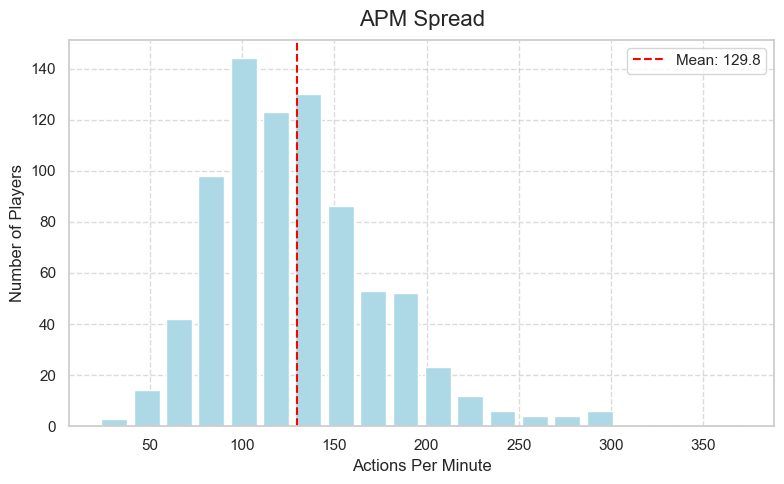


Shapiro-Wilk Test for APM:
P-value: 0.0000
Not normal!

Graph 10: APM distribution!


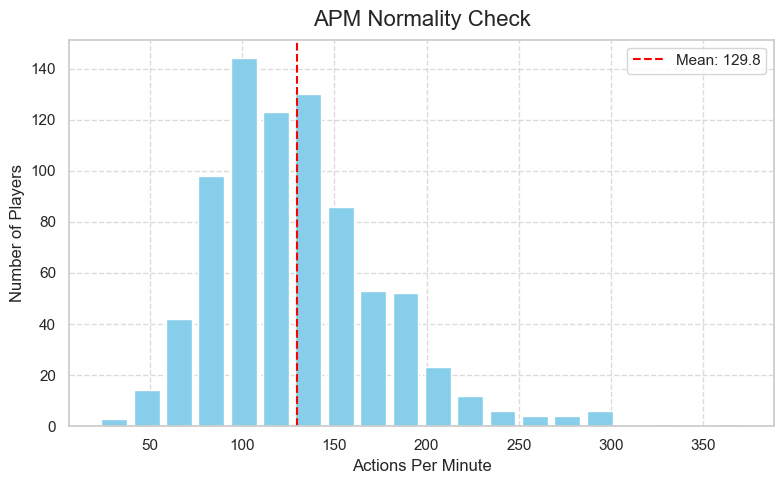


Normal Distribution:

Graph 11: Simulated normal APM!


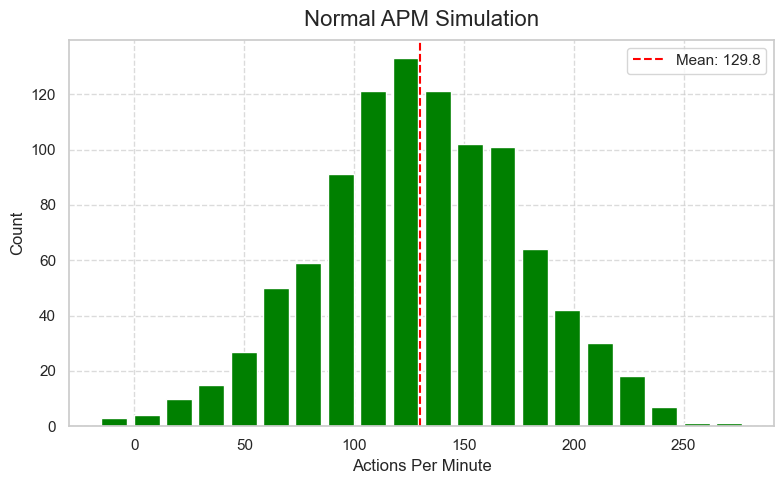


T-test: League 1 vs. 7 APM:
P-value: 0.0000
Different APMs!

Graph 12: APM for leagues 1 vs. 7!


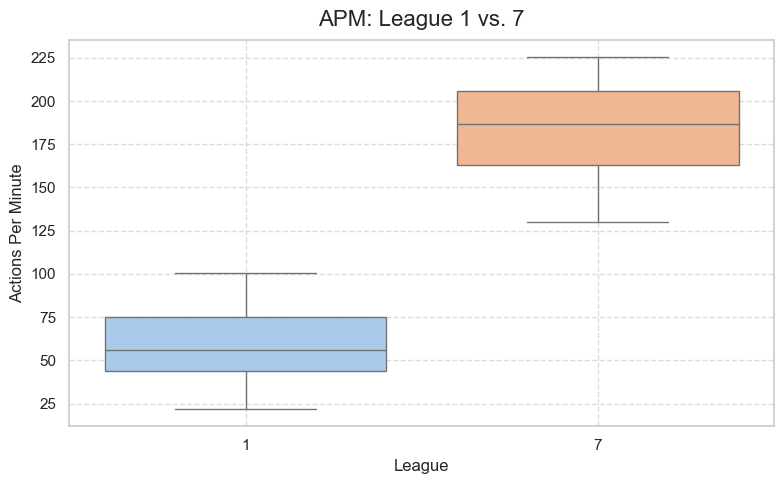


Done! Favorite StarCraft stat?


In [1]:
print("Welcome to SkillCraft II Data Science Project")

import pandas as pd
import numpy as np
pd.set_option('future.no_silent_downcasting', True)

# Load data
df = pd.read_excel('SkillCraft1_Dataset.xlsx')
print("Columns:", df.columns.tolist())
print("TOP 5 rows:")
print(df.head())
# Column meanings
info = {
    'GameID': 'Game session ID',
    'LeagueIndex': 'Skill level (1-8)',
    'Age': 'Player age',
    'HoursPerWeek': 'Weekly play hours',
    'TotalHours': 'Total hours played',
    'APM': 'Actions per minute',
    'SelectByHotkeys': 'Hotkey selections',
    'AssignToHotkeys': 'Hotkey assignments',
    'UniqueHotkeys': 'Different hotkeys used',
    'MinimapAttacks': 'Minimap attacks',
    'MinimapRightClicks': 'Minimap right-clicks',
    'NumberOfPACs': 'Perception-action cycles',
    'GapBetweenPACs': 'Time between PACs',
    'ActionLatency': 'Reaction delay',
    'ActionsInPAC': 'Actions per PAC',
    'TotalMapExplored': 'Map explored',
    'WorkersMade': 'Workers made',
    'UniqueUnitsMade': 'Unit types made',
    'ComplexUnitsMade': 'Advanced units',
    'ComplexAbilitiesUsed': 'Special abilities',
    'PACsPerMinute': 'PACs per minute',
    'IsElite': 'APM > 200'
}
print("\nColumn meanings:")
for col, desc in info.items():
    print(f"{col}: {desc}")

# Before cleaning
print("\nBefore cleaning:")
print(df.info())
print("Description")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())

# Clean data
df = df.replace("?", np.nan)
df = df.replace(0, np.nan)
df['IsElite'] = df['APM'] > 200
print("\nAfter replacing '?' and 0 with NaN:")
print(df.isnull().sum())
df_cleaned = df.dropna()
print("\nAfter cleaning:")
print(df_cleaned.info())
print("\nMissing values:")
print(df_cleaned.isnull().sum())
print(f"Rows left: {len(df_cleaned)}")

# Visualizations
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore, shapiro, ttest_ind
sns.set(style='whitegrid')

# Graph 1: Players per league
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='LeagueIndex', hue='LeagueIndex', data=df_cleaned, palette='crest', legend=False)
plt.title('Players per League', fontsize=16, pad=10)
plt.xlabel('League Level', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)
total = len(df_cleaned)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 3, f'{height/total:.1%}', ha="center", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
print("\nGraph 1: Players in each league!")
plt.tight_layout()
plt.show()

# Graph 2: Action latency with trendline
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['ActionLatency'], bins=30, color='tomato', alpha=0.7)
# Add trendline
x = np.linspace(df_cleaned['ActionLatency'].min(), df_cleaned['ActionLatency'].max(), 100)
coefficients = np.polyfit(df_cleaned['ActionLatency'].index, df_cleaned['ActionLatency'], 1)
trendline = np.poly1d(coefficients)
plt.plot(x, trendline(x), color='blue', linestyle='--', label='Trendline')
plt.title('Action Latency with Trendline', fontsize=16, pad=10)
plt.xlabel('Latency (ms)', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
print("\nGraph 2: How fast are players reacting with trend!")
plt.tight_layout()
plt.show()

# Graph 3: APM by league
plt.figure(figsize=(10, 6))
sns.lineplot(x='LeagueIndex', y='APM', data=df_cleaned, estimator='mean', errorbar=('ci', 95), marker='o', color='darkblue', linewidth=2)
plt.title('Average APM by League', fontsize=16, pad=10)
plt.xlabel('League Level', fontsize=12)
plt.ylabel('Actions Per Minute', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
print("\nGraph 3: APM trends across leagues!")
plt.tight_layout()
plt.show()

# Graph 4: Workers vs. complex units
wc = df_cleaned.groupby('LeagueIndex')[['WorkersMade', 'ComplexUnitsMade']].sum()
plt.figure(figsize=(12, 6))
wc.plot(kind='bar', stacked=True, colormap='Set2', width=0.8)
plt.title('Workers vs. Complex Units', fontsize=16, pad=10)
plt.xlabel('League Level', fontsize=12)
plt.ylabel('Total Units Made', fontsize=12)
plt.legend(["Workers", "Complex Units"], loc='upper left', fontsize=10)
max_h = wc.sum(axis=1).max() * 1.05
for i, total in enumerate(wc.sum(axis=1)):
    plt.text(i, total, f'{int(total)}', ha='center', va='bottom', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
print("\nGraph 4: Units built by league!")
plt.tight_layout()
plt.show()

# Graph 5: APM means
plt.figure(figsize=(12, 6))
sns.pointplot(x='LeagueIndex', y='APM', hue='LeagueIndex', data=df_cleaned, palette='Set2', estimator='mean', 
              errorbar='sd', markers='o', capsize=0.2, linestyle='-', linewidth=1)
plt.title('APM by League', fontsize=16, pad=10)
plt.xlabel('League Level', fontsize=12)
plt.ylabel('Actions Per Minute', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
print("\nGraph 5: Average APM per league!")
plt.tight_layout()
plt.show()

# Graph 6: Latency vs. APM
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_cleaned, x='ActionLatency', y='APM', hue='IsElite', palette='deep', s=100, alpha=0.6)
plt.title('Latency vs. APM', fontsize=16, pad=10)
plt.xlabel('Latency (ms)', fontsize=12)
plt.ylabel('Actions Per Minute', fontsize=12)
plt.legend(title='Elite (APM > 200)', title_fontsize=12, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
print("\nGraph 6: Speed vs. reaction time!")
plt.tight_layout()
plt.show()

# Graph 7: Correlations
cols = ['APM', 'ActionLatency', 'GapBetweenPACs', 'NumberOfPACs', 'WorkersMade']
plt.figure(figsize=(10, 6))
sns.heatmap(df_cleaned[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 10})
plt.title('Metric Correlations', fontsize=16, pad=10)
plt.tight_layout()
print("\nGraph 7: How metrics connect!")
plt.show()

# EDA
print("\nEDA: Digging Deeper!")

# Stats summary
print("\nStats Summary:")
stats = df_cleaned.describe()
print(stats)
print(f"\nFastest APM: {stats['APM']['max']:.1f}")
print(f"Quickest latency: {stats['ActionLatency']['min']:.1f} ms")

# Correlations
print("\nTop Correlations:")
corr = df_cleaned[cols].corr()
high_corrs = corr.unstack().sort_values().drop_duplicates()
print(high_corrs[(high_corrs > 0.5) | (high_corrs < -0.5)][1:6])

# Outliers
print("\nOutliers:")
check_cols = ['APM', 'ActionLatency', 'GapBetweenPACs']
z = df_cleaned[check_cols].apply(zscore)
outliers = (z.abs() > 3).any(axis=1)
print(f"Outlier players: {outliers.sum()}")
print(df_cleaned[outliers][['LeagueIndex', 'APM', 'ActionLatency', 'GapBetweenPACs']].head())

# Graph 8: Outlier boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_cleaned[check_cols], palette='pastel')
plt.title('Metric Outliers', fontsize=16, pad=10)
plt.ylabel('Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
print("\nGraph 8: Spotting extreme players!")
plt.tight_layout()
plt.show()

# Stats Introduction
print("\nStats Intro: Easy Number Crunching!")

# 1. Descriptive Stats
print("\nMean and Median APM:")
print(f"Mean APM: {df_cleaned['APM'].mean():.1f}")
print(f"Median APM: {df_cleaned['APM'].median():.1f}")
plt.figure(figsize=(8, 5))
plt.hist(df_cleaned['APM'], bins=20, color='lightblue', rwidth=0.8)
plt.axvline(df_cleaned['APM'].mean(), color='red', linestyle='--', label=f'Mean: {df_cleaned['APM'].mean():.1f}')
plt.title('APM Spread', fontsize=16, pad=10)
plt.xlabel('Actions Per Minute', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
print("\nGraph 9: APM histogram!")
plt.tight_layout()
plt.show()

# 2. Shapiro-Wilk
print("\nShapiro-Wilk Test for APM:")
stat, p = shapiro(df_cleaned['APM'])
print(f"P-value: {p:.4f}")
print("Normal curve?" if p > 0.05 else "Not normal!")
plt.figure(figsize=(8, 5))
plt.hist(df_cleaned['APM'], bins=20, color='skyblue', rwidth=0.8)
plt.axvline(df_cleaned['APM'].mean(), color='red', linestyle='--', label=f'Mean: {df_cleaned['APM'].mean():.1f}')
plt.title('APM Normality Check', fontsize=16, pad=10)
plt.xlabel('Actions Per Minute', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
print("\nGraph 10: APM distribution!")
plt.tight_layout()
plt.show()

# 3. Normal Distribution
print("\nNormal Distribution:")
m = df_cleaned['APM'].mean()
s = df_cleaned['APM'].std()
norm_data = np.random.normal(m, s, 1000)  # Increased to 1000 for smoother curve
plt.figure(figsize=(8, 5))
plt.hist(norm_data, bins=20, color='green', rwidth=0.8)
plt.axvline(m, color='red', linestyle='--', label=f'Mean: {m:.1f}')
plt.title('Normal APM Simulation', fontsize=16, pad=10)
plt.xlabel('Actions Per Minute', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
print("\nGraph 11: Simulated normal APM!")
plt.tight_layout()
plt.show()

# 4. T-test
print("\nT-test: League 1 vs. 7 APM:")
l1 = df_cleaned[df_cleaned['LeagueIndex'] == 1]['APM']
l7 = df_cleaned[df_cleaned['LeagueIndex'] == 7]['APM']
t_stat, p = ttest_ind(l1, l7, equal_var=False)  # Welch's t-test for robustness
print(f"P-value: {p:.4f}")
print("Different APMs!" if p < 0.05 else "Similar APMs!")
plt.figure(figsize=(8, 5))
sns.boxplot(x='LeagueIndex', y='APM', hue='LeagueIndex', data=df_cleaned[df_cleaned['LeagueIndex'].isin([1, 7])], palette='pastel', legend=False)
plt.title('APM: League 1 vs. 7', fontsize=16, pad=10)
plt.xlabel('League', fontsize=12)
plt.ylabel('Actions Per Minute', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
print("\nGraph 12: APM for leagues 1 vs. 7!")
plt.tight_layout()
plt.show()

print("\nDone! Favorite StarCraft stat?")